In [ ]:
!pip install tensorflow tensorflow-text datasets evaluate nltk

In [ ]:
!pip install rouge_score

In [ ]:
!pip install -U datasets

In [ ]:
import tensorflow as tf
import tensorflow_text as tf_text
from tensorflow.keras import layers
from datasets import load_dataset
import evaluate
import numpy as np
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import numpy as np
import evaluate
import matplotlib.pyplot as plt

class SummarizationModel:
    def __init__(self,
                 model_type='lstm',
                 encoder_layer_specs=None,
                 decoder_layer_specs=None,
                 vocab_size=10000,
                 embedding_dim=256,
                 dropout_rate=0.3,
                 recurrent_dropout_rate=0.2,
                 l2_reg=1e-4):
        self.model_type = model_type.lower()

        self.encoder_layer_specs = encoder_layer_specs or [(512, 'tanh'), (256, 'tanh')]
        self.decoder_layer_specs = decoder_layer_specs or [(512, 'tanh'), (256, 'tanh')]

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.dropout_rate = dropout_rate
        self.recurrent_dropout_rate = recurrent_dropout_rate
        self.l2_reg = l2_reg

        self.tokenizer = None
        self.model = None

    def build_model(self, max_text_len=512, max_summary_len=128):
        encoder_inputs = layers.Input(shape=(max_text_len,), name='encoder_inputs')
        x_enc = layers.Embedding(self.vocab_size,
                                 self.embedding_dim,
                                 mask_zero=False,
                                 name='encoder_embedding')(encoder_inputs)

        for idx, (units, activation) in enumerate(self.encoder_layer_specs):
            if self.model_type == 'lstm':
                cell = layers.LSTM(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'encoder_lstm_{idx}'
                )
            elif self.model_type == 'gru':
                cell = layers.GRU(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'encoder_gru_{idx}'
                )
            else:  # 'rnn'
                cell = layers.SimpleRNN(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'encoder_rnn_{idx}'
                )

            x_enc = layers.Bidirectional(cell, name=f'bidir_enc_{idx}')(x_enc)

        encoder_outputs = x_enc
        decoder_inputs = layers.Input(shape=(max_summary_len,), name='decoder_inputs')
        x_dec = layers.Embedding(self.vocab_size,
                                 self.embedding_dim,
                                 mask_zero=False,
                                 name='decoder_embedding')(decoder_inputs)

        for idx, (units, activation) in enumerate(self.decoder_layer_specs):
            if self.model_type == 'lstm':
                x_dec = layers.LSTM(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'decoder_lstm_{idx}'
                )(x_dec)
            elif self.model_type == 'gru':
                x_dec = layers.GRU(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'decoder_gru_{idx}'
                )(x_dec)
            else:  # 'rnn'
                x_dec = layers.SimpleRNN(
                    units,
                    activation=activation,
                    return_sequences=True,
                    dropout=self.dropout_rate,
                    recurrent_dropout=self.recurrent_dropout_rate,
                    kernel_regularizer=regularizers.l2(self.l2_reg),
                    name=f'decoder_rnn_{idx}'
                )(x_dec)

        # Удаляем маску перед TimeDistributed, чтобы избежать OperatorNotAllowedInGraphError
        x_dec = layers.Lambda(lambda x: x, mask=lambda inp, m: None, name='remove_mask')(x_dec)

        decoder_outputs = layers.TimeDistributed(
            layers.Dense(self.vocab_size, activation='softmax'),
            name='decoder_output'
        )(x_dec)

        self.model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                                    outputs=decoder_outputs)
        optimizer = tf.optimizer = tf.keras.optimizers.AdamW(learning_rate=0.02)
        self.model.compile(
            optimizer= optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        self.model.summary()

    def inference_summary(self, input_sequence, max_summary_len=128):
        """
        Делает «greedy decoding» для одного входного примера.
        input_sequence: ndarray формы (1, max_text_len), уже токенизированный и падденговый.
        """
        dummy_decoder_input = np.zeros((1, max_summary_len), dtype=np.int32)
        preds = self.model.predict([input_sequence, dummy_decoder_input], verbose=0)[0]
        predicted_ids = np.argmax(preds, axis=-1)

        words = []
        for idx in predicted_ids:
            if idx == 0:
                continue
            word = self.tokenizer.index_word.get(idx, '')
            if not word:
                continue
            words.append(word)
        return ' '.join(words)

    def evaluate_metrics(self, raw_texts, raw_references,
                         max_text_len=512, max_summary_len=128):
        """
        Оценивает ROUGE, BLEU и METEOR на списке сырых текстов и эталонных сводок.
        """
        preds = []
        for text in raw_texts:
            seq = self.tokenizer.texts_to_sequences([text])
            seq = tf.keras.preprocessing.sequence.pad_sequences(
                seq, maxlen=max_text_len, padding='post'
            )
            seq = np.array(seq)
            summary = self.inference_summary(seq, max_summary_len=max_summary_len)
            preds.append(summary)

        rouge = evaluate.load('rouge')
        bleu = evaluate.load('bleu')
        meteor = evaluate.load('meteor')

        rouge_res = rouge.compute(predictions=preds, references=raw_references)
        bleu_res = bleu.compute(predictions=preds, references=raw_references)
        meteor_res = meteor.compute(predictions=preds, references=raw_references)

        print("=== Оценка модели ===")
        print("ROUGE:", rouge_res)
        print("BLEU:", bleu_res)
        print("METEOR:", meteor_res)

    def plot_training_history(self, history):
        """
        Строит графики потерь и точности по эпохам в одном рисунке с subplots.
        history: объект History, возвращённый model.fit().
        """
        hist = history.history
        epochs = range(1, len(hist['loss']) + 1)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

        # Loss
        ax1.plot(epochs, hist['loss'], label='train_loss')
        if 'val_loss' in hist:
            ax1.plot(epochs, hist['val_loss'], label='val_loss')
        ax1.set_title('Training & Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()

        # Accuracy
        ax2.plot(epochs, hist['accuracy'], label='train_accuracy')
        if 'val_accuracy' in hist:
            ax2.plot(epochs, hist['val_accuracy'], label='val_accuracy')
        ax2.set_title('Training & Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()

        plt.tight_layout()
        plt.show()


In [ ]:
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

dataset = load_dataset("billsum", split="ca_test")
texts = dataset["text"]
summaries = dataset["summary"]
VOCAB_SIZE = 8000
MAX_TEXT_LEN = 512
MAX_SUMMARY_LEN = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts + summaries)
text_sequences = tokenizer.texts_to_sequences(texts)
summary_sequences = tokenizer.texts_to_sequences(summaries)
encoder_input_data = pad_sequences(text_sequences, maxlen=MAX_TEXT_LEN, padding='post')
decoder_target_data = pad_sequences(summary_sequences, maxlen=MAX_SUMMARY_LEN, padding='post')
decoder_input_data = np.zeros_like(decoder_target_data)
decoder_input_data[:, 1:] = decoder_target_data[:, :-1]
decoder_input_data[:, 0] = tokenizer.word_index["<OOV>"]


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
split_idx = int(0.8 * len(texts))

train_texts = texts[:split_idx]
train_summaries = summaries[:split_idx]

raw_val_texts = texts[split_idx:]
raw_val_summaries = summaries[split_idx:]

encoder_input_train = encoder_input_data[:split_idx]
decoder_input_train = decoder_input_data[:split_idx]
decoder_target_train = decoder_target_data[:split_idx]

encoder_input_val = encoder_input_data[split_idx:]
decoder_input_val = decoder_input_data[split_idx:]
decoder_target_val = decoder_target_data[split_idx:]

In [ ]:
VOCAB_SIZE = 8000
EMBEDDING_DIM = 256
MAX_TEXT_LEN = 512
MAX_SUM_LEN = 128

encoder_layers = [(512, 'tanh'), (256, 'tanh')]
decoder_layers = [(256, 'tanh'),(512,"tanh")]

model = SummarizationModel(
    model_type='lstm',
    encoder_layer_specs=encoder_layers,
    decoder_layer_specs=decoder_layers,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    dropout_rate=0.3,             # 30% Dropout
    recurrent_dropout_rate=0.2,   # 20% Recurrent Dropout
    l2_reg=1e-4                   # небольшая L2-регуляризация
)

model.tokenizer = tokenizer
model.build_model(max_text_len=MAX_TEXT_LEN, max_summary_len=MAX_SUM_LEN)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 128, 256)  │  2,048,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_0      │ (None, 128, 256)  │    525,312 │ decoder_embeddin… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_1      │ (None, 128, 512)  │  1,574,912 │ decoder_lstm_0[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ remove_mask         │ (None, 128, 512)  │          0 │ decoder_lstm_1[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 128, 8000) │  4,104,000 │ remove_mask[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,252,224 (31.48 MB)

 Trainable params: 8,252,224 (31.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
from tensorflow.keras.callbacks import Callback
import evaluate

class MetricsCallback(Callback):
    def __init__(self,
                 val_texts,
                 val_summaries,
                 tokenizer,
                 model_obj,
                 max_text_len,
                 max_sum_len,
                 sample_size=50):
        super().__init__()
        self.val_texts = val_texts
        self.val_summaries = val_summaries
        self.tokenizer = tokenizer
        self.model_obj = model_obj
        self.max_text_len = max_text_len
        self.max_sum_len = max_sum_len
        self.sample_size = min(sample_size, len(val_texts))

        self.rouge = evaluate.load('rouge')
        self.bleu = evaluate.load('bleu')
        self.meteor = evaluate.load('meteor')

    def on_epoch_end(self, epoch, logs=None):
        idxs = np.random.choice(len(self.val_texts), self.sample_size, replace=False)
        sample_texts = [self.val_texts[i] for i in idxs]
        sample_refs = [self.val_summaries[i] for i in idxs]

        preds, refs_filtered = [], []
        for text, ref in zip(sample_texts, sample_refs):
            seq = self.tokenizer.texts_to_sequences([text])
            seq = np.array(tf.keras.preprocessing.sequence.pad_sequences(
                seq, maxlen=self.max_text_len, padding='post'
            ))
            summary = self.model_obj.inference_summary(seq, max_summary_len=self.max_sum_len)

            # Фильтруем пустые предсказания или эталоны
            if (len(summary.strip()) > 0) and (len(ref.strip()) > 0):
                preds.append(summary)
                refs_filtered.append(ref)

        # Если после фильтрации нет ни одной пары, просто выводим нули
        if not preds:
            print(f"\n— Эпоха {epoch + 1}: все примеры пустые, BLEU=0, METEOR=0, ROUGE=0")
            return

        # Вычисляем ROUGE и METEOR без проблем (они корректно обрабатывают пустые строки/отсутствие совпадений)
        rouge_res = self.rouge.compute(predictions=preds, references=refs_filtered)
        meteor_res = self.meteor.compute(predictions=preds, references=refs_filtered)

        # Для BLEU оборачиваем в try/except, чтобы избежать ZeroDivisionError
        try:
            bleu_res = self.bleu.compute(predictions=preds, references=refs_filtered)
            bleu_score = bleu_res.get('bleu', 0.0)
        except ZeroDivisionError:
            bleu_score = 0.0

        print(f"\n— Эпоха {epoch + 1} (на {len(preds)} непустых примерах) —")
        print(f"  ROUGE-1 F1: {rouge_res['rouge1']:.4f}, ROUGE-2 F1: {rouge_res['rouge2']:.4f}, ROUGE-L F1: {rouge_res['rougeL']:.4f}")
        print(f"  BLEU: {bleu_score:.4f}")
        print(f"  METEOR: {meteor_res['meteor']:.4f}")


Epoch 1/25


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.0505 - loss: 7.9865 - val_accuracy: 0.0976 - val_loss: 6.7143
Epoch 2/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 936ms/step - accuracy: 0.0975 - loss: 6.5440 - val_accuracy: 0.1036 - val_loss: 6.3876
Epoch 3/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 935ms/step - accuracy: 0.1109 - loss: 6.5768 - val_accuracy: 0.1495 - val_loss: 6.8921
Epoch 4/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 951ms/step - accuracy: 0.1813 - loss: 6.2958 - val_accuracy: 0.2630 - val_loss: 5.4116
Epoch 5/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 931ms/step - accuracy: 0.2948 - loss: 4.9844 - val_accuracy: 0.3225 - val_loss: 4.7832
Epoch 6/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3406 - loss: 4.3578 - val_accuracy: 0.3440 - val_loss: 4.5149
Epoch 7/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 938ms/step - accuracy: 0.3616 - loss: 4.0249 - val_accuracy: 0.3556 - val_loss: 4.4088
Epoch 8/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 929ms/step - accuracy: 0.3887 - loss: 3.7259 - val_accuracy: 0.3702 - va

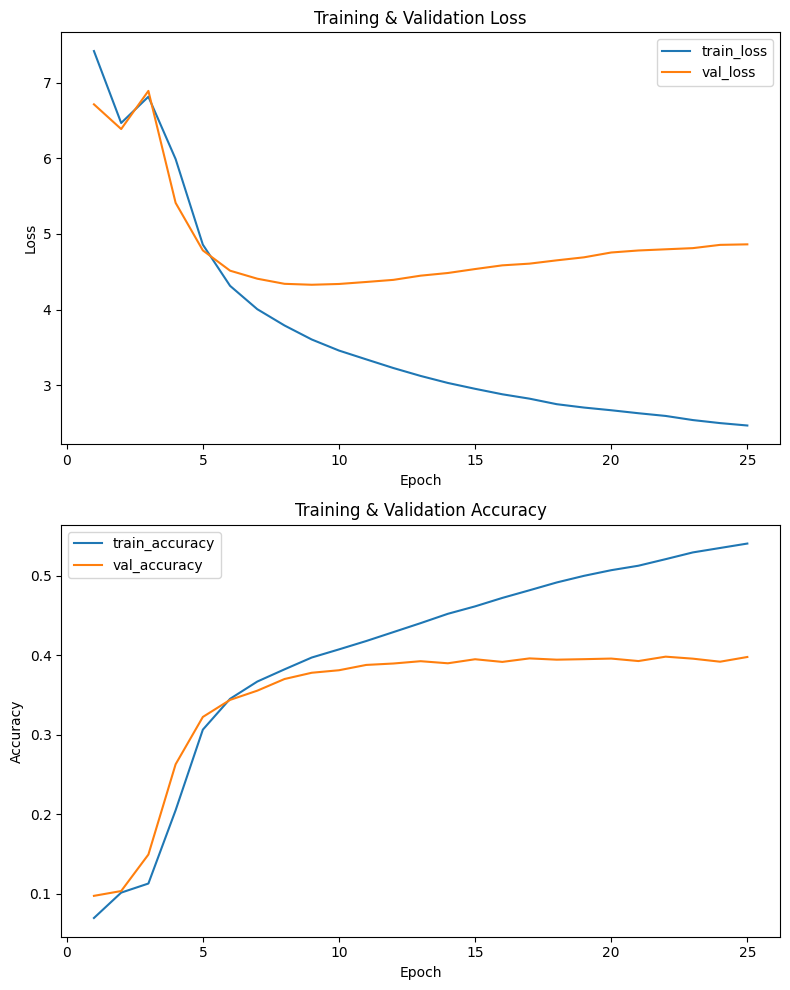

In [ ]:
metrics_cb = MetricsCallback(
    val_texts=raw_val_texts,
    val_summaries=raw_val_summaries,
    tokenizer=tokenizer,
    model_obj=model,
    max_text_len=MAX_TEXT_LEN,
    max_sum_len=128,
    sample_size=50
)

history = model.model.fit(
    [encoder_input_train, decoder_input_train],
    decoder_target_train,
    batch_size=32,
    epochs=25,
    validation_data=([encoder_input_val, decoder_input_val], decoder_target_val),
)

model.plot_training_history(history)


In [ ]:
test_text = raw_val_texts[0]
print("Исходный текст:\n", test_text[:500], "...\n")  # печатаем первые 500 символов

# Токенизация и паддинг
seq = tokenizer.texts_to_sequences([test_text])
seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_TEXT_LEN, padding='post')
seq = np.array(seq)  # форма (1, MAX_TEXT_LEN)

# Генерируем сводку
generated_summary = model.inference_summary(seq, max_summary_len=128)
print("Сгенерированная сводка:\n", generated_summary, "\n")

# Выводим эталонную сводку для сравнения
print("Эталонная сводка:\n", raw_val_summaries[0])


Исходный текст:
 The people of the State of California do enact as follows:


SECTION 1.
It is the intent of the Legislature to explore alternate approaches to ensure the continuation of broad coverage of pediatric hearing benefits upon expiration of this mandate, including exploring ways to add pediatric hearing as an essential health benefit, without incurring ongoing state costs.
SECTION 1.
SEC. 2.
Section 1367.72 is added to the Health and Safety Code, to read:
1367.72.
(a) (1) A health care service plan con ...

Сгенерированная сводка:
 to this 

Эталонная сводка:
 Existing law, the Knox-Keene Health Care Service Plan Act of 1975, provides for the licensure and regulation of health care service plans by the Department of Managed Health Care and makes a willful violation of the act a crime. Existing law also provides for the regulation of health insurers by the Department of Insurance. Existing law requires health care service plan contracts and health insurance policies to provide

In [ ]:
VOCAB_SIZE = 8000
EMBEDDING_DIM = 256
MAX_TEXT_LEN = 512
MAX_SUM_LEN = 128

encoder_layers = [(256, 'tanh'), (128, 'tanh')]
decoder_layers = [(128, 'tanh'), (256, 'tanh')]

model = SummarizationModel(
    model_type='lstm',
    encoder_layer_specs=encoder_layers,
    decoder_layer_specs=decoder_layers,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    dropout_rate=0.3,             # 30% Dropout
    recurrent_dropout_rate=0.2,   # 20% Recurrent Dropout
    l2_reg=1e-4                   # небольшая L2-регуляризация
)

model.tokenizer = tokenizer
model.build_model(max_text_len=MAX_TEXT_LEN, max_summary_len=MAX_SUM_LEN)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 128, 256)  │  2,048,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_0      │ (None, 128, 128)  │    197,120 │ decoder_embeddin… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_1      │ (None, 128, 256)  │    394,240 │ decoder_lstm_0[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ remove_mask         │ (None, 128, 256)  │          0 │ decoder_lstm_1[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 128, 8000) │  2,056,000 │ remove_mask[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,695,360 (17.91 MB)

 Trainable params: 4,695,360 (17.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.2700 - loss: 4.6312 - val_accuracy: 0.3138 - val_loss: 4.5605
Epoch 2/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 870ms/step - accuracy: 0.3343 - loss: 4.1862 - val_accuracy: 0.3370 - val_loss: 4.4177
Epoch 3/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 924ms/step - accuracy: 0.3623 - loss: 3.9410 - val_accuracy: 0.3522 - val_loss: 4.3246
Epoch 4/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 867ms/step - accuracy: 0.3730 - loss: 3.7979 - val_accuracy: 0.3613 - val_loss: 4.2707
Epoch 5/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 859ms/step - accuracy: 0.3809 - loss: 3.6734 - val_accuracy: 0.3686 - val_loss: 4.2326
Epoch 6/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 859ms/step - accuracy: 0.3925 - loss: 3.5559 - val_accuracy: 0.3777 - val_loss: 4.2182
Epoch 7/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 855ms/step - accuracy: 0.4148 - loss: 3.3699 - val_accuracy: 0.3839 - val_loss: 4.2145
Epoch 8/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 855ms/step - accuracy: 0.4211 - loss: 3.2891 - val_accuracy: 0.3871 -

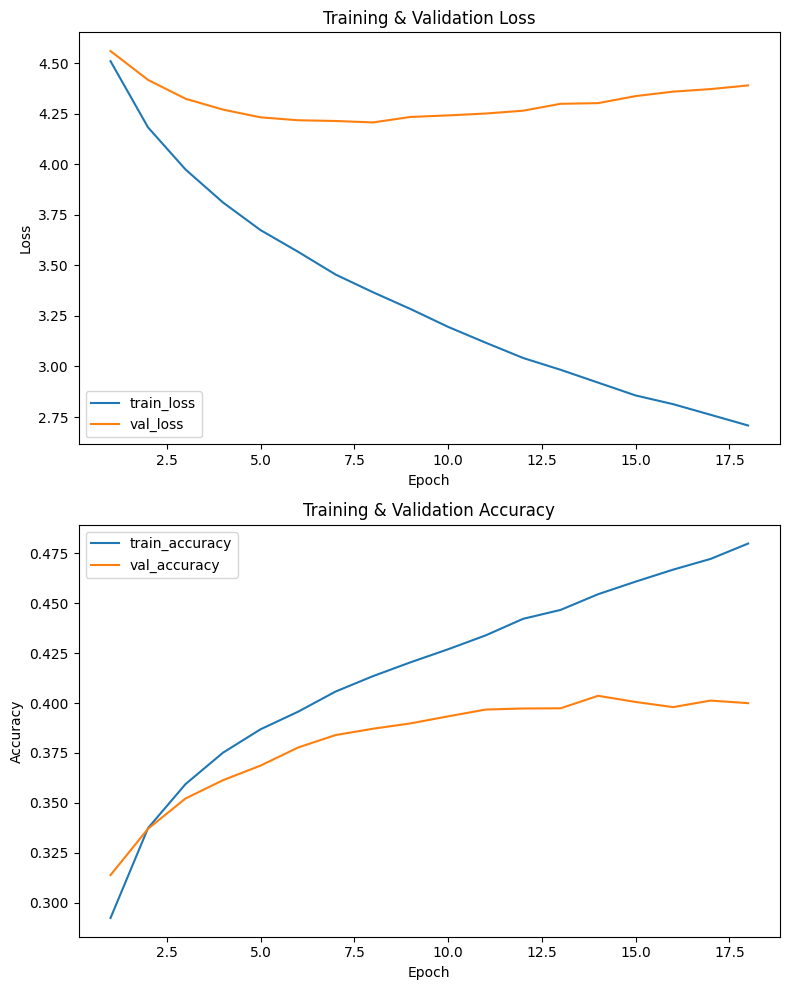

In [ ]:
metrics_cb = MetricsCallback(
    val_texts=raw_val_texts,
    val_summaries=raw_val_summaries,
    tokenizer=tokenizer,
    model_obj=model,
    max_text_len=MAX_TEXT_LEN,
    max_sum_len=128,
    sample_size=50
)

history = model.model.fit(
    [encoder_input_train, decoder_input_train],
    decoder_target_train,
    batch_size=32,
    epochs=18,
    validation_data=([encoder_input_val, decoder_input_val], decoder_target_val),
)

# После завершения .fit() просто вызываем:
model.plot_training_history(history)


In [ ]:
test_text = raw_val_texts[0]
print("Исходный текст:\n", test_text[:500], "...\n")  # печатаем первые 500 символов

# Токенизация и паддинг
seq = tokenizer.texts_to_sequences([test_text])
seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_TEXT_LEN, padding='post')
seq = np.array(seq)  # форма (1, MAX_TEXT_LEN)

# Генерируем сводку
generated_summary = model.inference_summary(seq, max_summary_len=128)
print("Сгенерированная сводка:\n", generated_summary, "\n")

# Выводим эталонную сводку для сравнения
print("Эталонная сводка:\n", raw_val_summaries[0])


Исходный текст:
 The people of the State of California do enact as follows:


SECTION 1.
It is the intent of the Legislature to explore alternate approaches to ensure the continuation of broad coverage of pediatric hearing benefits upon expiration of this mandate, including exploring ways to add pediatric hearing as an essential health benefit, without incurring ongoing state costs.
SECTION 1.
SEC. 2.
Section 1367.72 is added to the Health and Safety Code, to read:
1367.72.
(a) (1) A health care service plan con ...

Сгенерированная сводка:
  

Эталонная сводка:
 Existing law, the Knox-Keene Health Care Service Plan Act of 1975, provides for the licensure and regulation of health care service plans by the Department of Managed Health Care and makes a willful violation of the act a crime. Existing law also provides for the regulation of health insurers by the Department of Insurance. Existing law requires health care service plan contracts and health insurance policies to provide covera

In [ ]:
VOCAB_SIZE = 8000
EMBEDDING_DIM = 256
MAX_TEXT_LEN = 512
MAX_SUM_LEN = 128

encoder_layers = [(256, 'tanh'), (128, 'tanh')]
decoder_layers = [(128, 'tanh'), (256, 'tanh')]

model = SummarizationModel(
    model_type='lstm',
    encoder_layer_specs=encoder_layers,
    decoder_layer_specs=decoder_layers,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    dropout_rate=0.3,             # 30% Dropout
    recurrent_dropout_rate=0.2,   # 20% Recurrent Dropout
    l2_reg=1e-4                   # небольшая L2-регуляризация
)

model.tokenizer = tokenizer
model.build_model(max_text_len=MAX_TEXT_LEN, max_summary_len=MAX_SUM_LEN)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 128, 256)  │  2,048,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_0      │ (None, 128, 128)  │    197,120 │ decoder_embeddin… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm_1      │ (None, 128, 256)  │    394,240 │ decoder_lstm_0[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ remove_mask         │ (None, 128, 256)  │          0 │ decoder_lstm_1[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 128, 8000) │  2,056,000 │ remove_mask[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,695,360 (17.91 MB)

 Trainable params: 4,695,360 (17.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/18


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 974ms/step - accuracy: 0.0575 - loss: 7.3938 - val_accuracy: 0.0791 - val_loss: 6.7778
Epoch 2/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 858ms/step - accuracy: 0.0724 - loss: 6.6856 - val_accuracy: 0.0791 - val_loss: 6.6211
Epoch 3/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - accuracy: 0.0770 - loss: 6.4052 - val_accuracy: 0.0795 - val_loss: 6.0432
Epoch 4/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 28s 896ms/step - accuracy: 0.0914 - loss: 5.7574 - val_accuracy: 0.1815 - val_loss: 5.3244
Epoch 5/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 868ms/step - accuracy: 0.2111 - loss: 5.0134 - val_accuracy: 0.2821 - val_loss: 4.7943
Epoch 6/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - accuracy: 0.3031 - loss: 4.4398 - val_accuracy: 0.3209 - val_loss: 4.5556
Epoch 7/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - accuracy: 0.3327 - loss: 4.1803 - val_accuracy: 0.3359 - val_loss: 4.4108
Epoch 8/18
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 849ms/step - accuracy: 0.3526 - loss: 3.9709 - val_accuracy: 0.350

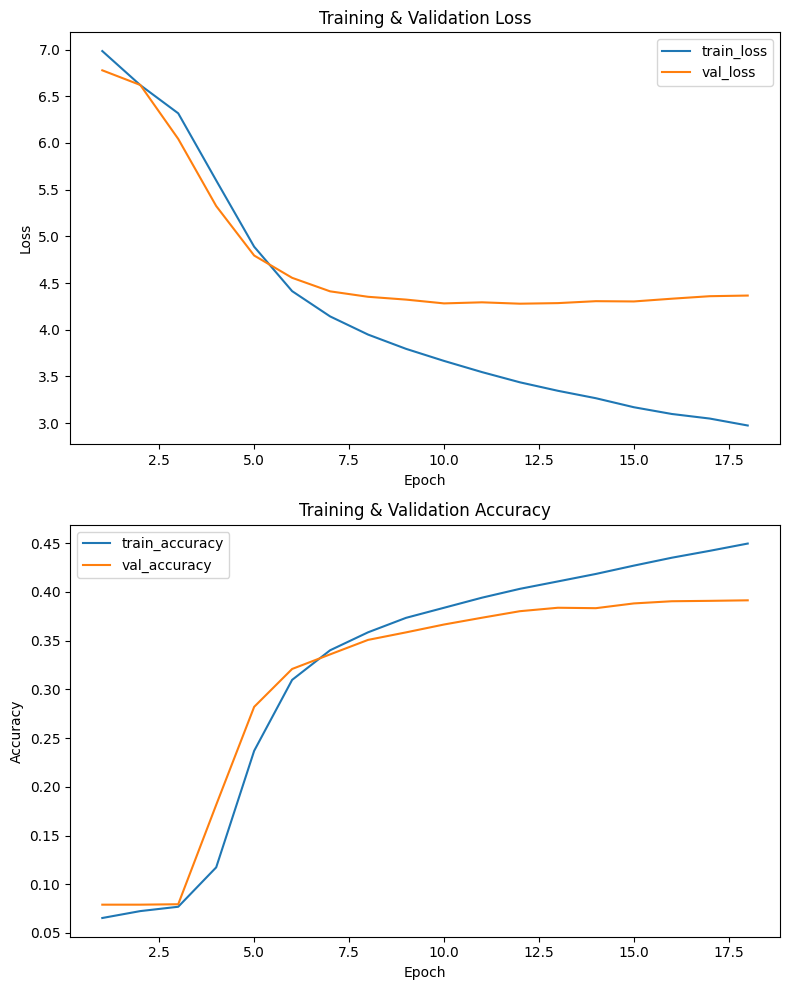

In [ ]:
# Допустим, вы уже тренировались так:
metrics_cb = MetricsCallback(
    val_texts=raw_val_texts,
    val_summaries=raw_val_summaries,
    tokenizer=tokenizer,
    model_obj=model,
    max_text_len=MAX_TEXT_LEN,
    max_sum_len=128,
    sample_size=50
)

history = model.model.fit(
    [encoder_input_train, decoder_input_train],
    decoder_target_train,
    batch_size=32,
    epochs=18,
    validation_data=([encoder_input_val, decoder_input_val], decoder_target_val),
)

# После завершения .fit() просто вызываем:
model.plot_training_history(history)


In [ ]:
test_text = raw_val_texts[0]
print("Исходный текст:\n", test_text[:500], "...\n")  # печатаем первые 500 символов

# Токенизация и паддинг
seq = tokenizer.texts_to_sequences([test_text])
seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_TEXT_LEN, padding='post')
seq = np.array(seq)  # форма (1, MAX_TEXT_LEN)

# Генерируем сводку
generated_summary = model.inference_summary(seq, max_summary_len=128)
print("Сгенерированная сводка:\n", generated_summary, "\n")

# Выводим эталонную сводку для сравнения
print("Эталонная сводка:\n", raw_val_summaries[0])


Исходный текст:
 The people of the State of California do enact as follows:


SECTION 1.
It is the intent of the Legislature to explore alternate approaches to ensure the continuation of broad coverage of pediatric hearing benefits upon expiration of this mandate, including exploring ways to add pediatric hearing as an essential health benefit, without incurring ongoing state costs.
SECTION 1.
SEC. 2.
Section 1367.72 is added to the Health and Safety Code, to read:
1367.72.
(a) (1) A health care service plan con ...

Сгенерированная сводка:
 mandated provisions 

Эталонная сводка:
 Existing law, the Knox-Keene Health Care Service Plan Act of 1975, provides for the licensure and regulation of health care service plans by the Department of Managed Health Care and makes a willful violation of the act a crime. Existing law also provides for the regulation of health insurers by the Department of Insurance. Existing law requires health care service plan contracts and health insurance policie